# Company Hiring Score

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

matplotlib.rcParams['figure.dpi'] = 120

In [2]:
INPUT_PATH  = Path("../output/adzuna_sector_fullfield_output/companies_with_sector_hiring.csv")
OUTPUT_DIR  = Path("../output/hiring_score")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "company_hiring_score.csv"


In [3]:
df = pd.read_csv(INPUT_PATH, low_memory=False, dtype=str)
print(f"len：{len(df):,} ，col:{len(df.columns)} ")

required = [
    "CompanyNumber", "CompanyName", "primary_sector",
    "sector_hiring_score", "CompanyStatus", "company_age_years",
    "Accounts_AccountCategory", "Accounts_LastMadeUpDate",
    "Accounts_NextDueDate", "Mortgages_NumMortCharges",
    "Mortgages_NumMortOutstanding", "Mortgages_NumMortSatisfied",
]
missing = [c for c in required if c not in df.columns]
if missing:
    print(f"missing fields: {missing}")
else:
    print("ok")

has_conf_stmt = "ConfStmtLastMadeUpDate" in df.columns
print(f"  ConfStmtLastMadeUpDate: {'1' if has_conf_stmt else '0'}")

df["sector_hiring_score"] = pd.to_numeric(df["sector_hiring_score"], errors="coerce")
print(f"\nsector_hiring_score overview：")
print(df["sector_hiring_score"].describe().round(1).to_string())

len：3,415,689 ，col:37 
ok
  ConfStmtLastMadeUpDate: 0

sector_hiring_score overview：
count    3415689.0
mean          51.7
std           17.4
min           23.4
25%           52.4
50%           52.9
75%           64.1
max           72.5


## Factors


In [4]:
# Factor 1: Status 

ACTIVE_STATUSES = {"active"}

def status_factor(status) -> float:
    if pd.isna(status):
        return 0.0
    return 1.0 if str(status).strip().lower() in ACTIVE_STATUSES else 0.0


# Factor 2: Age 

def age_factor(age) -> float:
    if pd.isna(age):
        return 0.95   
    age = float(age)
    if age < 2:
        return 0.65
    elif age < 3:
        return 0.80
    elif age <= 7:
        return 1.15
    elif age <= 10:
        return 1.00
    else:
        return 0.90


# Factor 3: Scale (Account Category) 

SCALE_MAP_EXACT = {
    
    "dormant":                       0.0,

    "no accounts filed":             0.60,
    "accounts type not available":   0.70,
    
    "micro entity":                  0.85,
    "total exemption full":          0.90,
    "total exemption small":         0.90,
    "unaudited abridged":            0.95,
    "audited abridged":              0.95,
    
    "small":                         1.00,
    "small company":                 1.00,
    "medium":                        1.10,
    "medium sized":                  1.10,
    "full":                          1.05,
    "full accounts":                 1.05,
    
    "group":                         1.05,
    "group accounts":                1.05,
    "public limited company":        1.00,
    "initial":                       0.85,   
}

def scale_factor(category) -> float:
    if pd.isna(category):
        return 0.95
    
    c = " ".join(str(category).strip().lower().split())
    if c in SCALE_MAP_EXACT:
        return SCALE_MAP_EXACT[c]

    return 0.95


# Factor 4: Filing Freshness 

def filing_freshness_factor(last_accounts, next_due,
                             conf_stmt_last=None) -> float:
    today = pd.Timestamp.today().normalize()

    
    dt_next = pd.to_datetime(next_due, errors="coerce")
    if pd.notna(dt_next) and dt_next.normalize() < today:
        return 0.50   

    
    dt_last = pd.to_datetime(last_accounts, errors="coerce")
    if pd.isna(dt_last):
        score_accounts = 0.85
    else:
        days = (today - dt_last.normalize()).days
        if days <= 365:
            score_accounts = 1.00
        elif days <= 540:
            score_accounts = 0.85
        elif days <= 730:
            score_accounts = 0.70
        else:
            score_accounts = 0.55

    # Confirmation Statement
    if conf_stmt_last is not None:
        dt_conf = pd.to_datetime(conf_stmt_last, errors="coerce")
        if pd.isna(dt_conf):
            score_conf = 0.90
        else:
            days_conf = (today - dt_conf.normalize()).days
            if days_conf <= 365:
                score_conf = 1.00
            elif days_conf <= 540:
                score_conf = 0.90
            elif days_conf <= 730:
                score_conf = 0.75
            else:
                score_conf = 0.60
        return min(score_accounts, score_conf)   

    return score_accounts


# Factor 5: Financing History

def financing_factor(num_charges, num_outstanding,
                     num_satisfied) -> float:
    n_chg = pd.to_numeric(num_charges,     errors="coerce")
    n_out = pd.to_numeric(num_outstanding, errors="coerce")
    n_sat = pd.to_numeric(num_satisfied,   errors="coerce")

    n_chg = 0 if pd.isna(n_chg) else int(n_chg)
    n_out = 0 if pd.isna(n_out) else int(n_out)
    n_sat = 0 if pd.isna(n_sat) else int(n_sat)

    if n_out >= 3:
        return 0.85   
    elif n_out >= 1:
        return 0.95   
    elif n_chg >= 1 and n_sat >= 1:
        return 1.08   
    elif n_chg >= 1:
        return 1.03   
    else:
        return 1.00   


print(f"  status_factor('Active')          = {status_factor('Active')}")
print(f"  status_factor('Liquidation')     = {status_factor('Liquidation')}")
print(f"  age_factor(5)                    = {age_factor(5)}")
print(f"  age_factor(15)                   = {age_factor(15)}")
print(f"  scale_factor('DORMANT')          = {scale_factor('DORMANT')}")
print(f"  scale_factor('MICRO ENTITY')     = {scale_factor('MICRO ENTITY')}")
print(f"  scale_factor('FULL')             = {scale_factor('FULL')}")
print(f"  scale_factor('Total Exemption Full') = {scale_factor('Total Exemption Full')}")
print(f"  scale_factor('Unknown Category') = {scale_factor('Unknown Category')}")
print(f"  financing_factor(3, 0, 3)        = {financing_factor(3, 0, 3)}")
print(f"  financing_factor(0, 4, 0)        = {financing_factor(0, 4, 0)}")

  status_factor('Active')          = 1.0
  status_factor('Liquidation')     = 0.0
  age_factor(5)                    = 1.15
  age_factor(15)                   = 0.9
  scale_factor('DORMANT')          = 0.0
  scale_factor('MICRO ENTITY')     = 0.85
  scale_factor('FULL')             = 1.05
  scale_factor('Total Exemption Full') = 0.9
  scale_factor('Unknown Category') = 0.95
  financing_factor(3, 0, 3)        = 1.08
  financing_factor(0, 4, 0)        = 0.85


In [5]:
out = df.copy()

# status_factor 
out["status_factor"] = out["CompanyStatus"].apply(status_factor)

# age_factor
out["age_factor"] = pd.to_numeric(
    out["company_age_years"], errors="coerce"
).apply(age_factor)

# scale_factor 
out["scale_factor"] = out["Accounts_AccountCategory"].apply(scale_factor)

# filing_freshness_factor
conf_col = "ConfStmtLastMadeUpDate" if has_conf_stmt else None

out["filing_freshness_factor"] = out.apply(
    lambda r: filing_freshness_factor(
        r.get("Accounts_LastMadeUpDate"),
        r.get("Accounts_NextDueDate"),
        r.get(conf_col) if conf_col else None,
    ),
    axis=1,
)

# financing_factor
out["financing_factor"] = out.apply(
    lambda r: financing_factor(
        r.get("Mortgages_NumMortCharges"),
        r.get("Mortgages_NumMortOutstanding"),
        r.get("Mortgages_NumMortSatisfied"),
    ),
    axis=1,
)

factor_cols = [
    "status_factor", "age_factor", "scale_factor",
    "filing_freshness_factor", "financing_factor",
]


print(out[factor_cols].describe().round(3).to_string())

       status_factor   age_factor  scale_factor  filing_freshness_factor  financing_factor
count    3415689.000  3415689.000   3415689.000              3415689.000       3415689.000
mean           0.923        0.898         0.711                    0.785             0.992
std            0.267        0.180         0.286                    0.147             0.035
min            0.000        0.650         0.000                    0.500             0.850
25%            1.000        0.650         0.600                    0.700             1.000
50%            1.000        0.900         0.850                    0.850             1.000
75%            1.000        1.000         0.900                    0.850             1.000
max            1.000        1.150         1.100                    1.000             1.080


In [6]:

out["adjustment_factor"] = (
    out["age_factor"]
    * out["scale_factor"]
    * out["filing_freshness_factor"]
    * out["financing_factor"]
)

# clip  [0, 1.40]
out["adjustment_factor"] = out["adjustment_factor"].clip(0.0, 1.40)

# status=0 
out["company_hiring_score"] = (
    out["sector_hiring_score"]
    * out["adjustment_factor"]
    * out["status_factor"]
).round(1)

out["company_hiring_score"] = out["company_hiring_score"].fillna(0)

print(out["company_hiring_score"].describe().round(1).to_string())
print()
print(f"fill 0（status=0 OR dormant）: "
      f"{(out['company_hiring_score'] == 0).sum():,}")

count    3415689.0
mean          24.3
std           17.9
min            0.0
25%           10.5
50%           21.2
75%           39.1
max           99.0

fill 0（status=0 OR dormant）: 619,614


## output

In [7]:
preview_cols = [
    "CompanyNumber", "CompanyName", "primary_sector",
    "sector_hiring_score",
    "status_factor", "age_factor", "scale_factor",
    "filing_freshness_factor", "financing_factor",
    "adjustment_factor",
    "company_hiring_score",
]

print("Top 20（company_hiring_score desc）：")
out[preview_cols].sort_values(
    "company_hiring_score", ascending=False
).head(20).reset_index(drop=True)

Top 20（company_hiring_score desc）：


,CompanyNumber,CompanyName,primary_sector,sector_hiring_score,status_factor,age_factor,scale_factor,filing_freshness_factor,financing_factor,adjustment_factor,company_hiring_score
0,12384812,EXPENSEMATE LTD,Fast growth & emerging sector,72.5,1.0,1.15,1.10,1.0,1.08,1.3662,99.0
1,12386908,TEAMTEK GLOBAL LTD,Fast growth & emerging sector,72.5,1.0,1.15,1.05,1.0,1.08,1.3041,94.5
2,12370899,AHEAD UK SOLUTIONS LIMITED,Fast growth & emerging sector,72.5,1.0,1.15,1.05,1.0,1.08,1.3041,94.5
3,14375735,PS UK HOLDCO LIMITED,Fast growth & emerging sector,72.5,1.0,1.15,1.00,1.0,1.08,1.2420,90.0
4,12466144,MESTAG THERAPEUTICS LTD,Fast growth & emerging sector,72.5,1.0,1.15,1.00,1.0,1.08,1.2420,90.0
5,12228828,HAPPYSIGNALS UK LTD,Fast growth & emerging sector,72.5,1.0,1.15,1.00,1.0,1.08,1.2420,90.0
6,12616585,VOI TECHNOLOGY UK LTD,"Technology, legal & professional",64.1,1.0,1.15,1.10,1.0,1.08,1.3662,87.6
7,14479785,GRANTABRIDGE RESEARCH LIMITED,Fast growth & emerging sector,72.5,1.0,1.15,1.05,1.0,1.00,1.2075,87.5
8,13978639,ENFUCE UK LTD,Fast growth & emerging sector,72.5,1.0,1.15,1.05,1.0,1.00,1.2075,87.5
9,12704901,PROTOSTAR GROUP LIMITED,Fast growth & emerging sector,72.5,1.0,1.15,1.05,1.0,1.00,1.2075,87.5


/var/folders/bs/fv2zw8q92b53tbz4z0w21h700000gn/T/ipykernel_6328/1605758281.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,2].boxplot(sector_groups, labels=sector_labels,


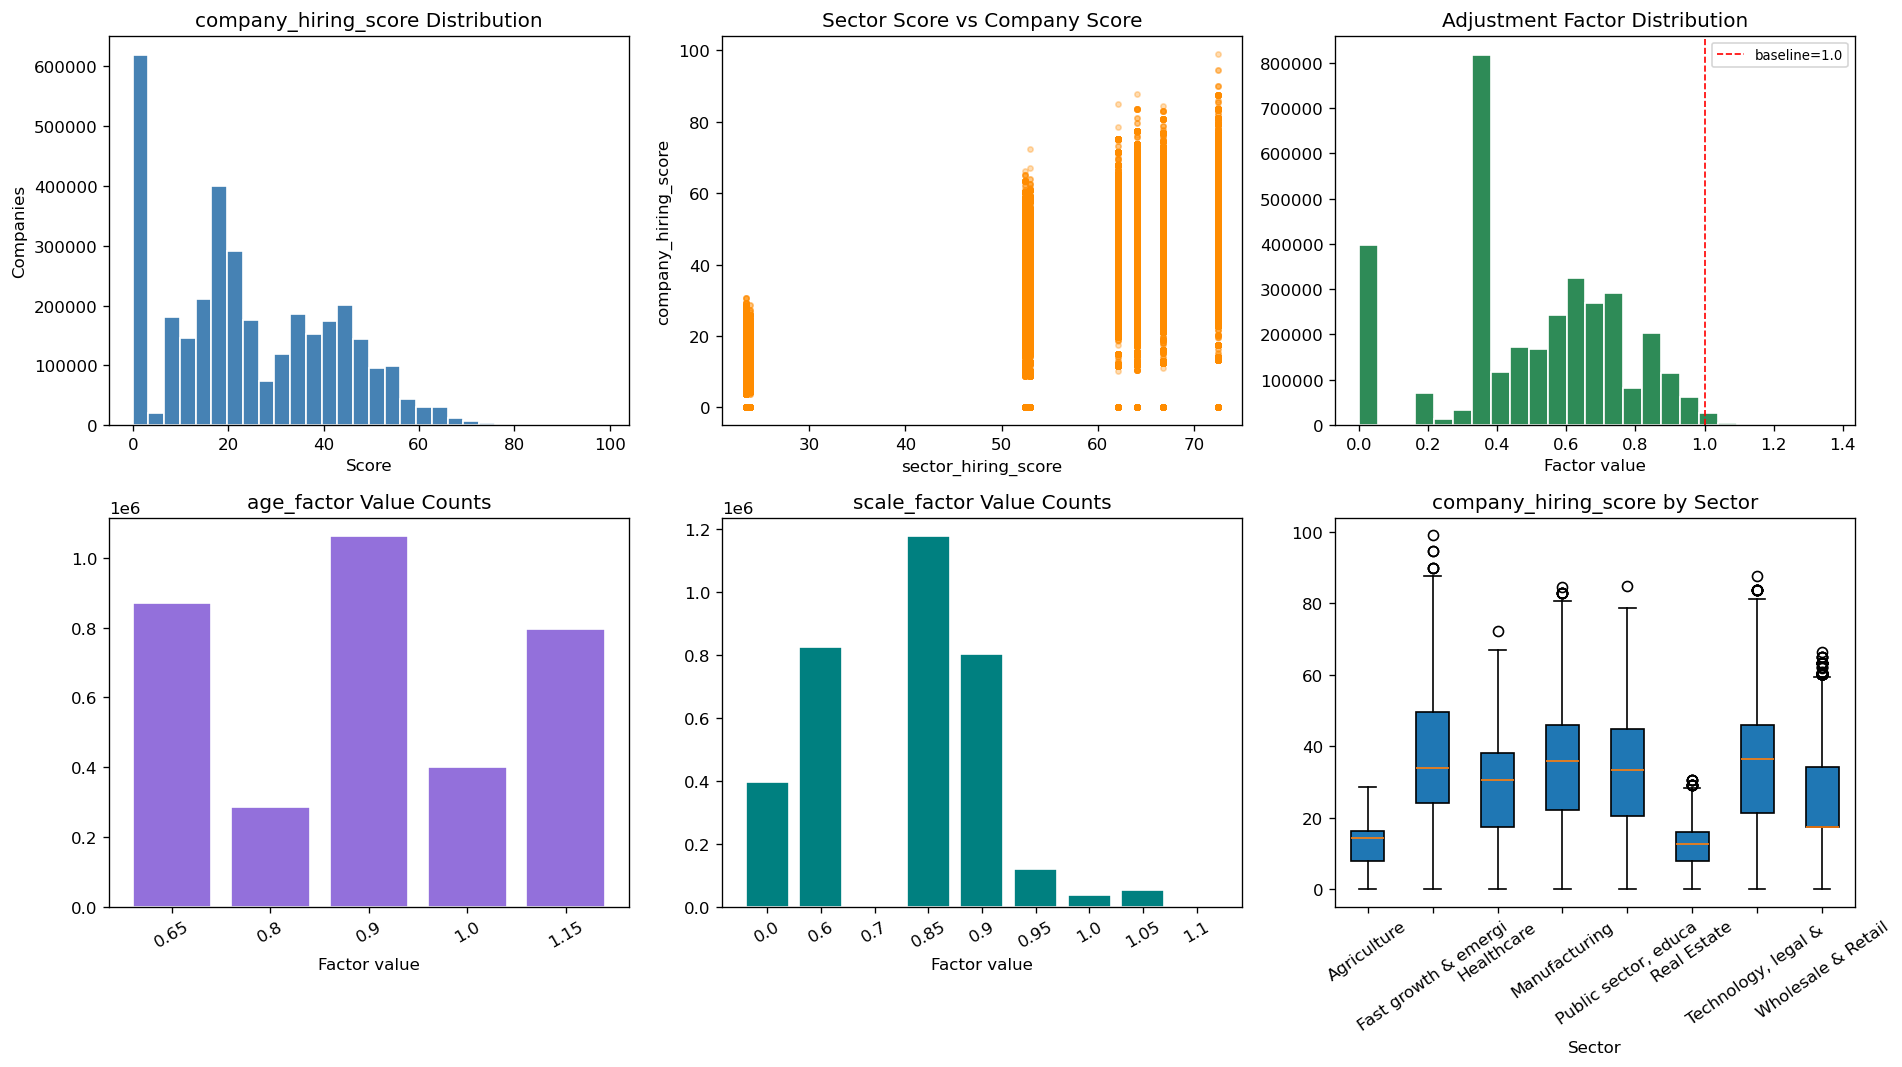

save: ../output/hiring_score/company_hiring_score_viz.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ① company_hiring_score 
axes[0,0].hist(
    out["company_hiring_score"].dropna(),
    bins=30, color="steelblue", edgecolor="white"
)
axes[0,0].set_title("company_hiring_score Distribution")
axes[0,0].set_xlabel("Score")
axes[0,0].set_ylabel("Companies")

# ② sector vs company score
axes[0,1].scatter(
    out["sector_hiring_score"],
    out["company_hiring_score"],
    alpha=0.3, s=10, color="darkorange"
)
axes[0,1].set_title("Sector Score vs Company Score")
axes[0,1].set_xlabel("sector_hiring_score")
axes[0,1].set_ylabel("company_hiring_score")

# ③ adjustment_factor 
axes[0,2].hist(
    out["adjustment_factor"].dropna(),
    bins=25, color="seagreen", edgecolor="white"
)
axes[0,2].axvline(1.0, color="red", linestyle="--", linewidth=1, label="baseline=1.0")
axes[0,2].set_title("Adjustment Factor Distribution")
axes[0,2].set_xlabel("Factor value")
axes[0,2].legend(fontsize=8)

# ④ age_factor 
age_vc = out["age_factor"].value_counts().sort_index()
axes[1,0].bar(age_vc.index.astype(str), age_vc.values,
              color="mediumpurple", edgecolor="white")
axes[1,0].set_title("age_factor Value Counts")
axes[1,0].set_xlabel("Factor value")
axes[1,0].tick_params(axis="x", rotation=30)

# ⑤ scale_factor 
scale_vc = out["scale_factor"].value_counts().sort_index()
axes[1,1].bar(scale_vc.index.astype(str), scale_vc.values,
              color="teal", edgecolor="white")
axes[1,1].set_title("scale_factor Value Counts")
axes[1,1].set_xlabel("Factor value")
axes[1,1].tick_params(axis="x", rotation=30)

# ⑥ sector company_hiring_score
sector_iter   = list(out.groupby("primary_sector", sort=True))
sector_groups = [grp["company_hiring_score"].dropna().values for _, grp in sector_iter]
sector_labels = [s[:20] for s, _ in sector_iter]
axes[1,2].boxplot(sector_groups, labels=sector_labels,
                  patch_artist=True)
axes[1,2].set_title("company_hiring_score by Sector")
axes[1,2].set_xlabel("Sector")
axes[1,2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "company_hiring_score_viz.png",
            bbox_inches="tight", dpi=120)
plt.show()
print(f"save: {OUTPUT_DIR / 'company_hiring_score_viz.png'}")

In [9]:

active_only = out[out["status_factor"] == 1.0]

factor_means = active_only[factor_cols[1:]].mean()  
print("factors mean")
for col, val in factor_means.items():
    direction = "↑ UP" if val > 1.0 else "↓ DOWN" if val < 1.0 else "→ NEUTRAL"
    print(f"  {col:<30} {val:.3f}  {direction}")

print()

# adjustment_factor by sector
print("AVG adjustment_factor by sector：")
print(
    active_only.groupby("primary_sector")["adjustment_factor"]
    .mean().round(3).sort_values(ascending=False).to_string()
)

factors mean
  age_factor                     0.895  ↓ DOWN
  scale_factor                   0.714  ↓ DOWN
  filing_freshness_factor        0.799  ↓ DOWN
  financing_factor               0.991  ↓ DOWN

AVG adjustment_factor by sector：
primary_sector
Agriculture                             0.563
Healthcare                              0.557
Public sector, education & charities    0.532
Technology, legal & professional        0.528
Manufacturing                           0.522
Fast growth & emerging sector           0.497
Real Estate                             0.491
Wholesale & Retail                      0.483


In [10]:
output_cols = [
    "CompanyNumber", "CompanyName", "primary_sector",
    "CompanyStatus", "company_age_years",
    "Accounts_AccountCategory",
    "sector_hiring_score",
    "status_factor", "age_factor", "scale_factor",
    "filing_freshness_factor", "financing_factor",
    "adjustment_factor",
    "company_hiring_score",
]

# hiring_signal_quality
if "hiring_signal_quality" in out.columns:
    output_cols.append("hiring_signal_quality")

# out[output_cols].to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print(f"output: {OUTPUT_PATH}")
print(f"  length: {len(out):,}")

output: ../output/hiring_score/company_hiring_score.csv
  length: 3,415,689
